In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tensorflow


EDA

In [ ]:
import random
import os
import glob
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers, Sequential
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
print(os.listdir('/content/drive/MyDrive/data'))

['train', 'test']


In [ ]:
import os
from PIL import Image
import numpy as np

# Specify absolute folder paths
folder_benign_train = '/content/drive/MyDrive/data/train/benign'
folder_malignant_train = '/content/drive/MyDrive/data/train/malignant'
folder_benign_test = '/content/drive/MyDrive/data/test/benign'
folder_malignant_test = '/content/drive/MyDrive/test/malignant'
read = lambda imname: np.asarray(Image.open(imname).convert("RGB"))

# Load in training pictures
ims_benign = [read(os.path.join(folder_benign_train, filename)) for filename in os.listdir(folder_benign_train)]
X_benign = np.array(ims_benign, dtype='uint8')
ims_malignant = [read(os.path.join(folder_malignant_train, filename)) for filename in os.listdir(folder_malignant_train)]
X_malignant = np.array(ims_malignant, dtype='uint8')

# Load in testing pictures
ims_benign = [read(os.path.join(folder_benign_test, filename)) for filename in os.listdir(folder_benign_test)]
X_benign_test = np.array(ims_benign, dtype='uint8')
ims_malignant = [read(os.path.join(folder_malignant_test, filename)) for filename in os.listdir(folder_malignant_test)]
X_malignant_test = np.array(ims_malignant, dtype='uint8')

# Create labels
y_benign = np.zeros(X_benign.shape[0])
y_malignant = np.ones(X_malignant.shape[0])


y_benign_test = np.zeros(X_benign_test.shape[0])
y_malignant_test = np.ones(X_malignant_test.shape[0])

# Merge data
X_train = np.concatenate((X_benign, X_malignant), axis = 0)

y_train = np.concatenate((y_benign, y_malignant), axis = 0).reshape(-1, 1)

X_test = np.concatenate((X_benign_test, X_malignant_test), axis = 0)
y_test = np.concatenate((y_benign_test, y_malignant_test), axis = 0).reshape(-1, 1)

# Shuffle data
s = np.arange(X_train.shape[0])
np.random.shuffle(s)
X_train = X_train[s]
y_train = y_train[s]
# Split validation data from train data
x_train, x_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.15,random_state=42)
# Shuffle test data
s = np.arange(X_test.shape[0])
np.random.shuffle(s)
X_test = X_test[s]
Y_test =y_test[s]

Y_test.shape

(430, 1)

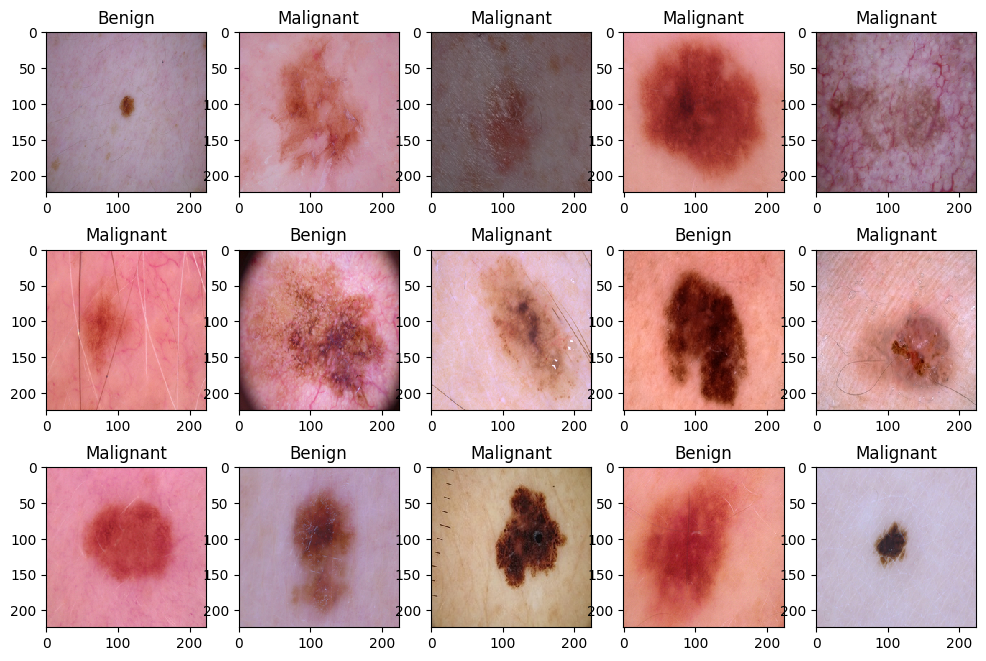

In [ ]:
w=40
h=30
fig=plt.figure(figsize=(12, 8))
columns = 5
rows = 3

for i in range(1, columns*rows +1):
    ax = fig.add_subplot(rows, columns, i)
    if y_train[i] == 0:
        ax.title.set_text('Benign')
    else:
        ax.title.set_text('Malignant')
    plt.imshow(X_train[i], interpolation='nearest')
plt.show()

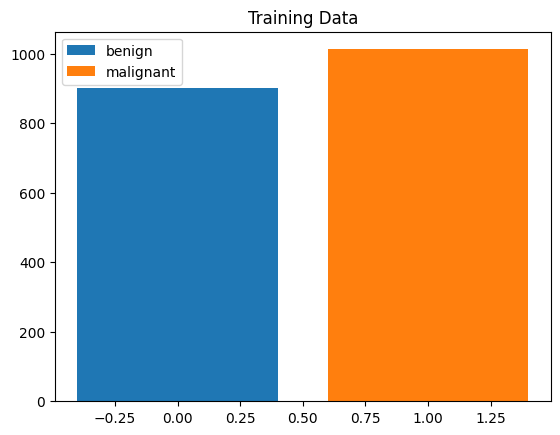

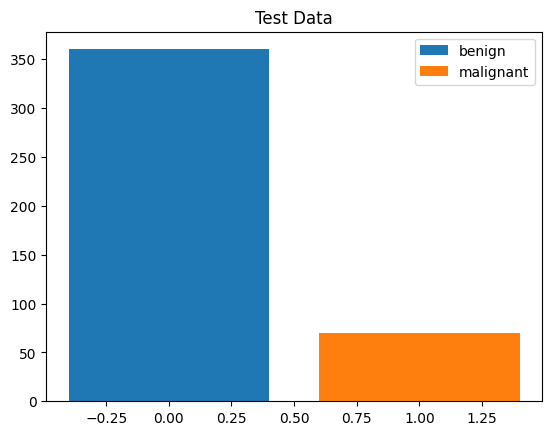

In [ ]:
plt.bar(0, y_train[np.where(y_train == 0)].shape[0], label = 'benign')
plt.bar(1, y_train[np.where(y_train == 1)].shape[0], label = 'malignant')
plt.legend()
plt.title("Training Data")
plt.show()

plt.bar(0, y_test[np.where(y_test == 0)].shape[0], label = 'benign')
plt.bar(1, y_test[np.where(y_test == 1)].shape[0], label = 'malignant')
plt.legend()
plt.title("Test Data")
plt.show()

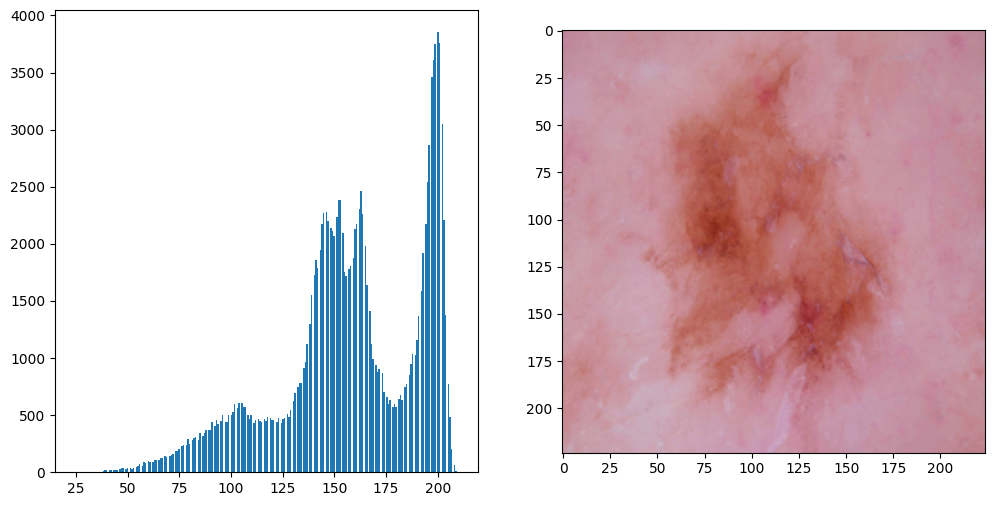

In [ ]:
def plot_histogram(a):
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.hist(a.ravel(),bins=255)
    plt.subplot(1,2,2)
    plt.imshow(a,vmin=0,vmax=1)
    plt.show()


plot_histogram(X_train[2])

Benign


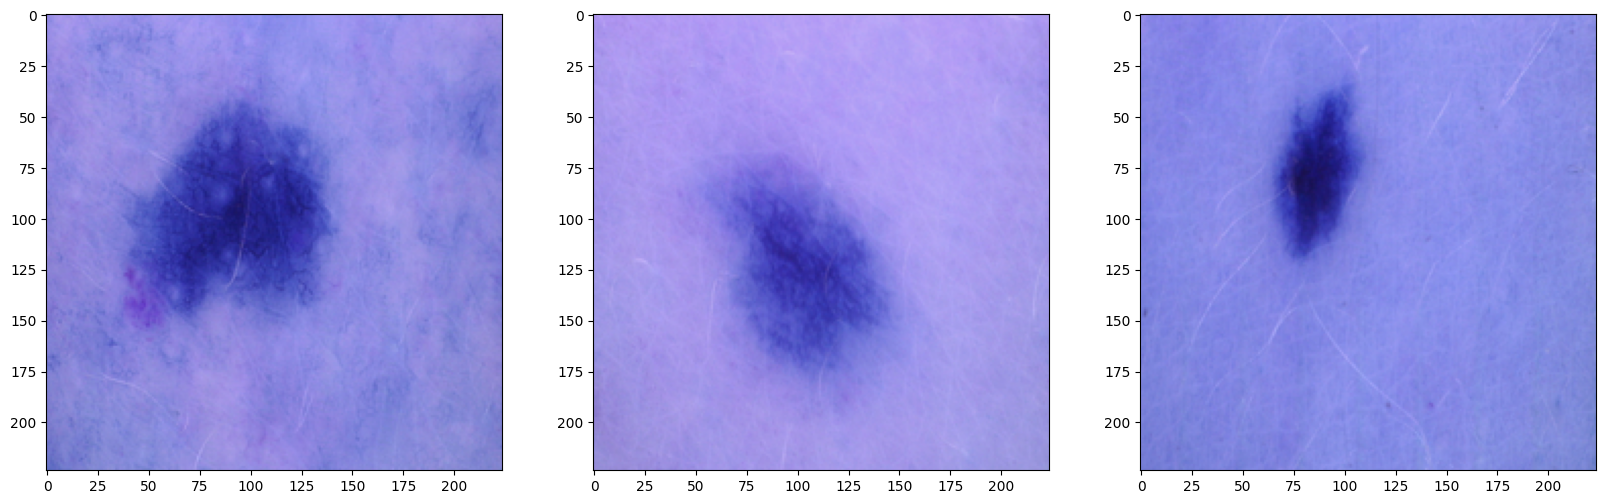

In [ ]:
import cv2

image_dir = "/content/drive/MyDrive/data/train/benign"
print("Benign")
glob_img = glob.glob(os.path.join(image_dir, '*.jpg'))

def plot(images):
    z = random.sample(images,3)
    plt.figure(figsize=(20,20))
    plt.subplot(131)
    plt.imshow(cv2.imread(z[0]))
    plt.subplot(132)
    plt.imshow(cv2.imread(z[1]))
    plt.subplot(133)
    plt.imshow(cv2.imread(z[2]))

plot(glob_img)

Malignant


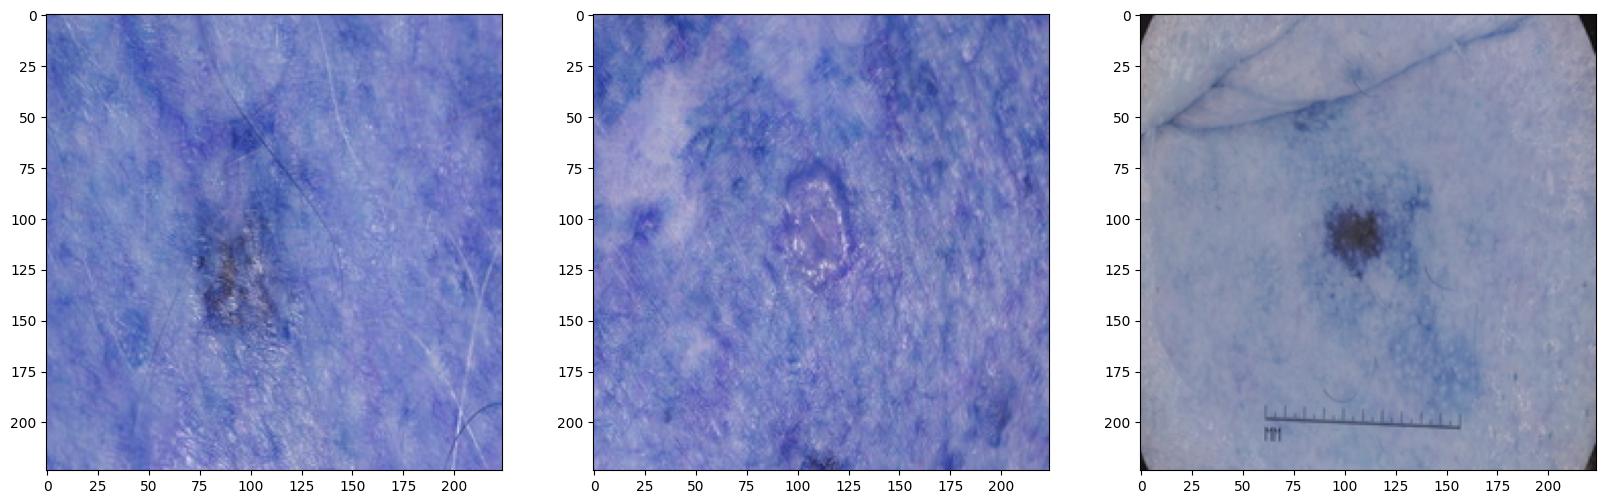

In [ ]:
image_dir = "/content/drive/MyDrive/data/train/malignant"
print("Malignant")
glob_img = glob.glob(os.path.join(image_dir, '*.jpg'))

def plot(images):
    z = random.sample(images,3)
    plt.figure(figsize=(20,20))
    plt.subplot(131)
    plt.imshow(cv2.imread(z[0]))
    plt.subplot(132)
    plt.imshow(cv2.imread(z[1]))
    plt.subplot(133)
    plt.imshow(cv2.imread(z[2]))

plot(glob_img)


Benign


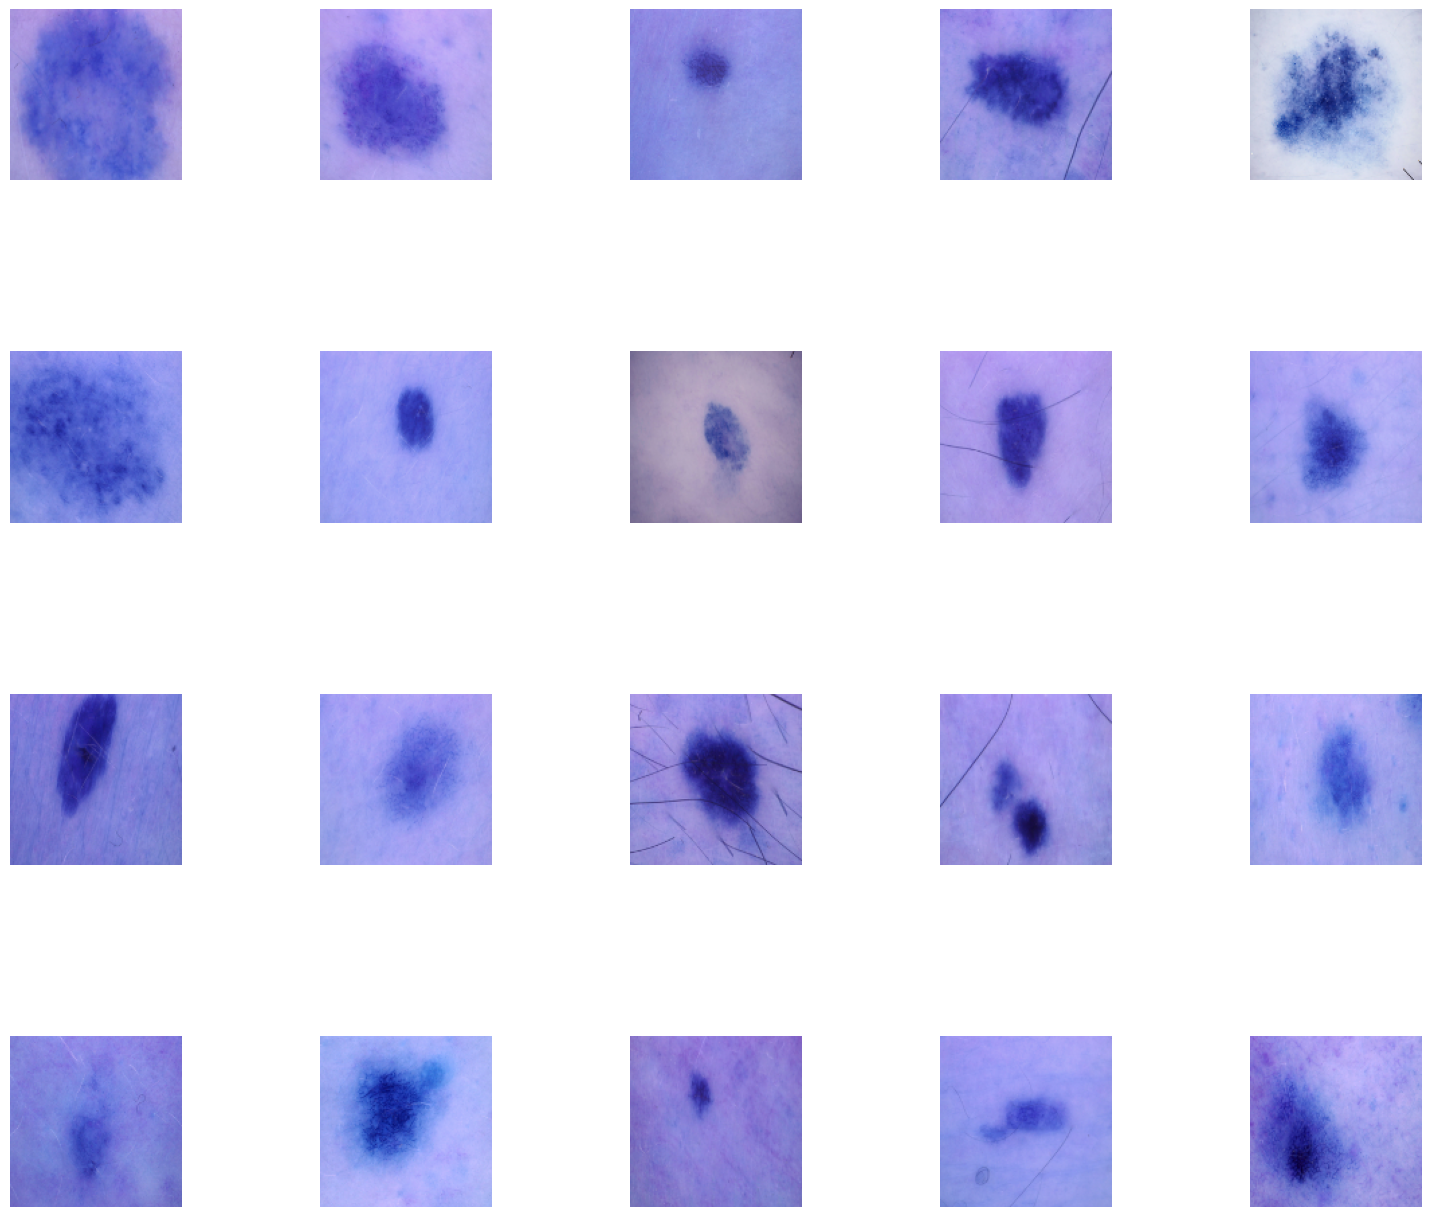

In [ ]:
import glob
import random
import cv2
import matplotlib.pyplot as plt

# Specify the path to the image directory
image_dir = "/content/drive/MyDrive/data/train/benign"
print("Benign")
glob_img = glob.glob(os.path.join(image_dir, '*.jpg'))
i_=0
plt.rcParams["figure.figsize"] =(20.0,20.0)
plt.subplots_adjust(wspace=0,hspace=1)
for i in  glob_img[0:20]:
    img=cv2.imread(i)
    img=cv2.resize(img,(128,128))
    plt.subplot(5,5,i_+1)
    plt.imshow(img);plt.axis("off")
    i_ +=1

plt.show()

Malignant


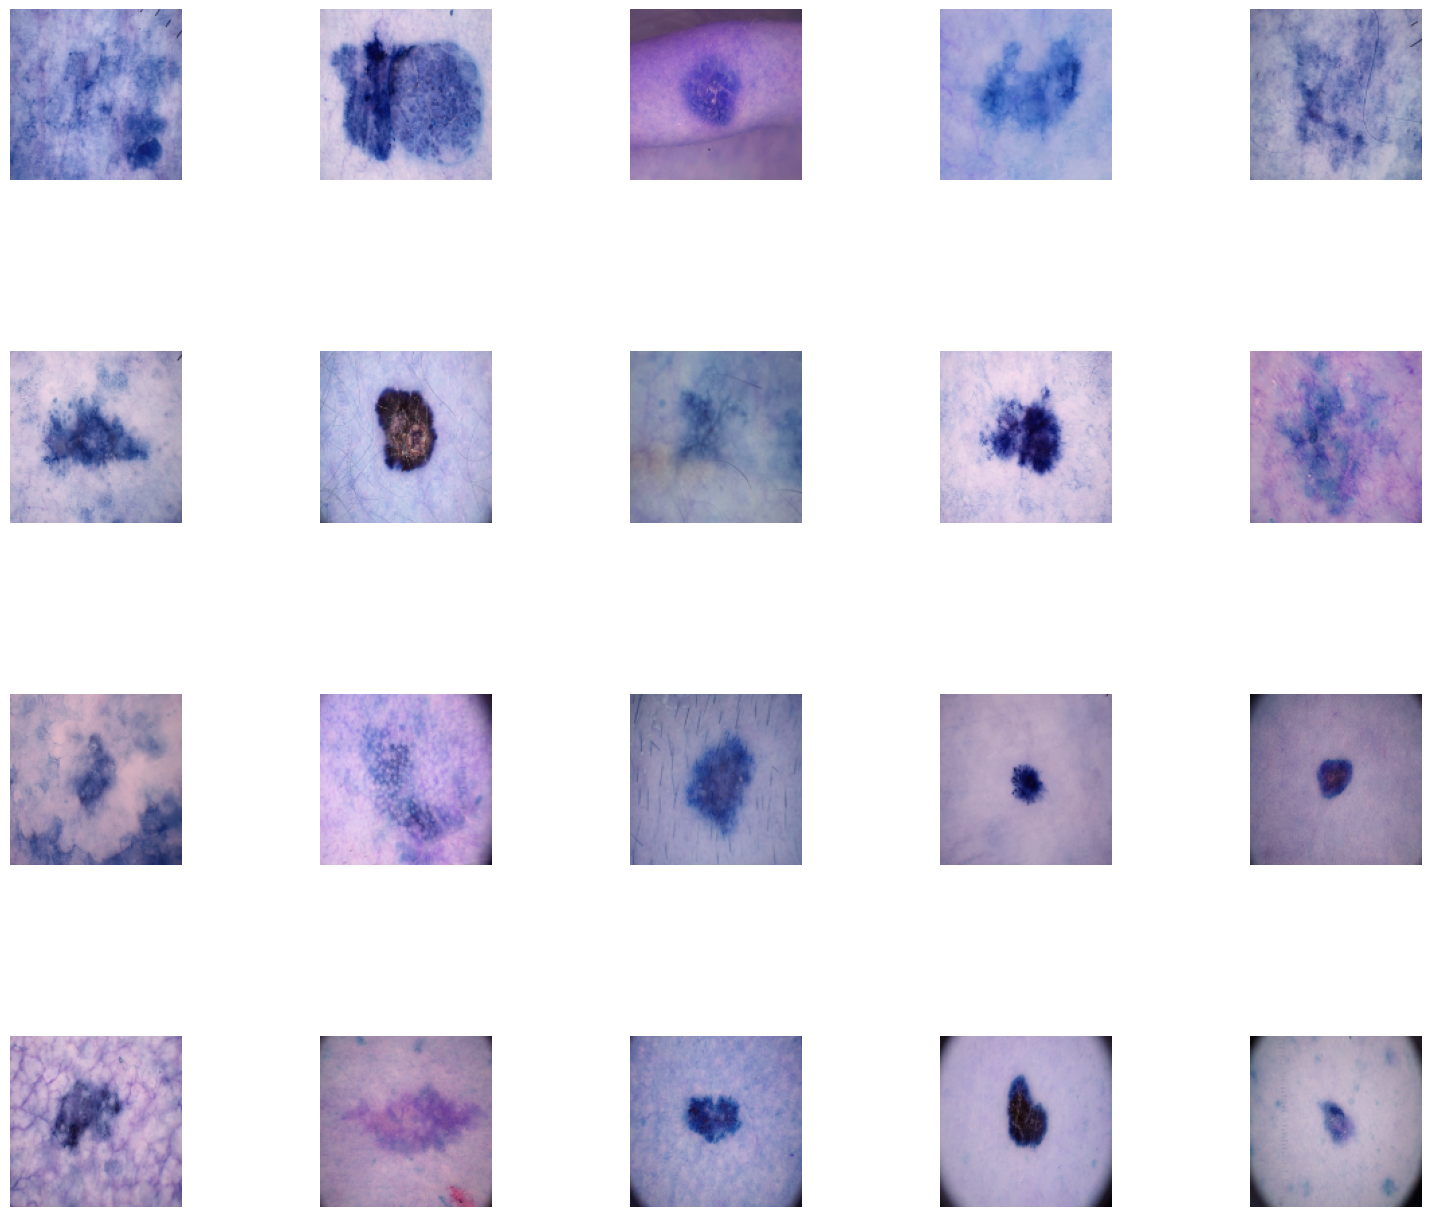

In [ ]:

# Specify the path to the image directory
image_dir = "/content/drive/MyDrive/data/train/malignant"
print("Malignant")
glob_img = glob.glob(os.path.join(image_dir, '*.jpg'))
i_=0
plt.rcParams["figure.figsize"] =(20.0,20.0)
plt.subplots_adjust(wspace=0,hspace=1)
for i in  glob_img[0:20]:
    img=cv2.imread(i)
    img=cv2.resize(img,(128,128))
    plt.subplot(5,5,i_+1)
    plt.imshow(img);plt.axis("off")
    i_ +=1

In [ ]:
%%time
train_images = glob.glob(f'{"/content/drive/MyDrive/data/train/"}**/*.jpg')
test_images = glob.glob(f'{"/content/drive/MyDrive/data/test/"}**/*.jpg')
# Get train & test set sizes
train_size = len(train_images)
test_size = len(test_images)

# Get dataset size
total = train_size + test_size

# View samples counts
print(f'train samples count:\t\t{train_size}')
print(f'test samples count:\t\t{test_size}')
print('=======================================')
print(f'TOTAL:\t\t\t\t{total}')


train samples count:		2253
test samples count:		660
TOTAL:				2913
CPU times: user 19.7 ms, sys: 861 µs, total: 20.5 ms
Wall time: 450 ms


resnet 50


In [ ]:
pip install keras


In [ ]:
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image
        width_shift_range=0.2,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images

datagen.fit(x_train)


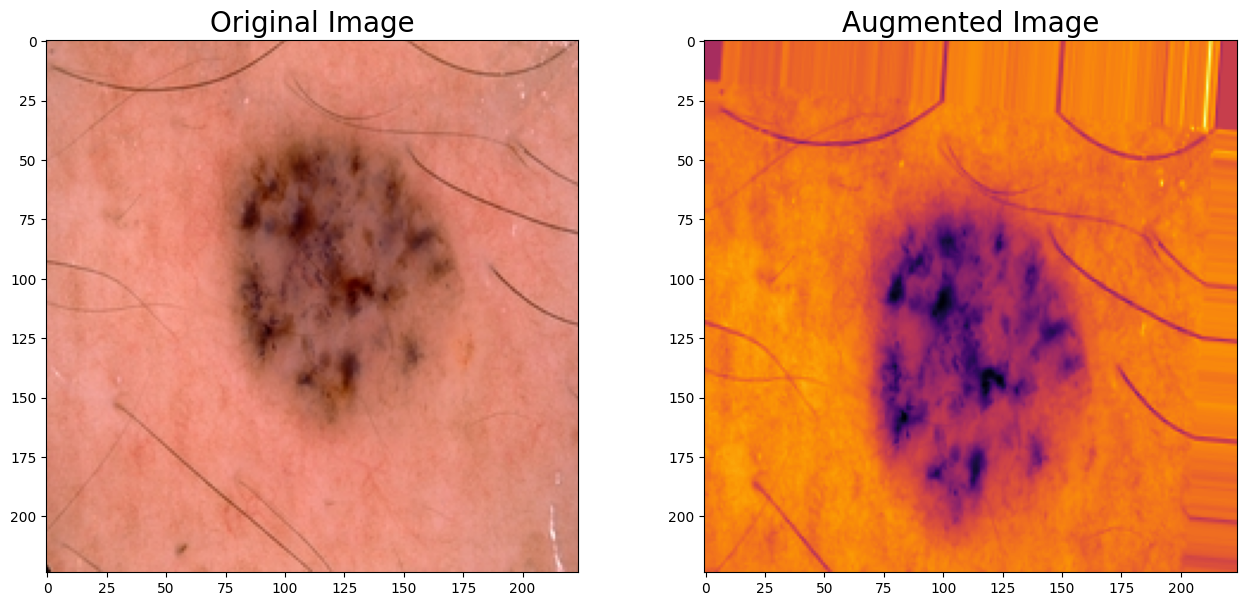

In [ ]:
index = 0

# Get the image at the chosen index
image = x_train[index]
image = np.expand_dims(image, axis=0)

# Generate augmented images
augmented_images = datagen.flow(image, batch_size=1)

# Get the first augmented image (as it's a generator)
augmented_image = augmented_images.next()[0]

# Convert to grayscale if needed
augmented_image_gray = tf.image.rgb_to_grayscale(augmented_image)

# Plot the original and augmented images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))
fig.tight_layout(pad=6.0)

ax1.set_title('Original Image', fontsize=20)
ax1.imshow(x_train[index], cmap='inferno')

ax2.set_title('Augmented Image', fontsize=20)
ax2.imshow(augmented_image_gray.numpy().squeeze(), cmap='inferno')

plt.show()

In [ ]:
from tensorflow.keras.applications.resnet_v2 import ResNet50V2
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=optimizers.Adam(lr=0.0001), loss='binary_crossentropy', metrics=['accuracy'])



94765736/94765736 [==============================] - 1s 0us/step


In [ ]:
y_train.shape
# Train the model using data generator
batch_size = 32
history = model.fit(datagen.flow(x_train, y_train, batch_size=batch_size),
                    steps_per_epoch=len(x_train) / batch_size, epochs=10,
                    validation_data=(x_val, y_val))

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

Epoch 1/10
59/59 [==============================] - 516s 9s/step - loss: 4.8948 - accuracy: 0.7661 - val_loss: 0.4909 - val_accuracy: 0.8521
Epoch 2/10
59/59 [==============================] - 468s 8s/step - loss: 0.4703 - accuracy: 0.8298 - val_loss: 0.3292 - val_accuracy: 0.8432
Epoch 3/10
59/59 [==============================] - 469s 8s/step - loss: 0.3680 - accuracy: 0.8413 - val_loss: 0.3420 - val_accuracy: 0.8521
Epoch 4/10
59/59 [==============================] - 447s 7s/step - loss: 0.3288 - accuracy: 0.8590 - val_loss: 0.3176 - val_accuracy: 0.8669
Epoch 5/10
59/59 [==============================] - 473s 8s/step - loss: 0.3087 - accuracy: 0.8663 - val_loss: 0.3416 - val_accuracy: 0.8639
Epoch 6/10
59/59 [==============================] - 473s 8s/step - loss: 0.3449 - accuracy: 0.8501 - val_loss: 0.3331 - val_accuracy: 0.8550
Epoch 7/10
59/59 [==============================] - 450s 8s/step - loss: 0.3102 - accuracy: 0.8590 - val_loss: 0.3259 - val_accuracy: 0.8609
Epoch 8/10
59

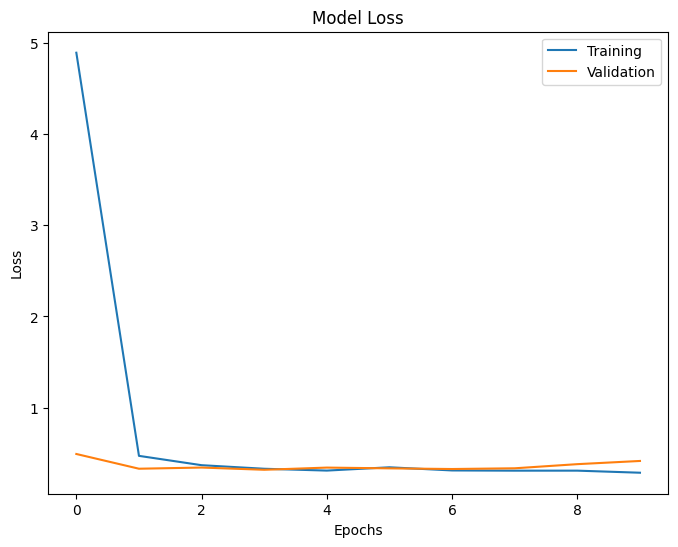

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have history from your training process
plt.figure(figsize=(8, 6))  # Adjust the figsize as needed
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

14/14 [==============================] - 82s 6s/step
0.8348837209302326


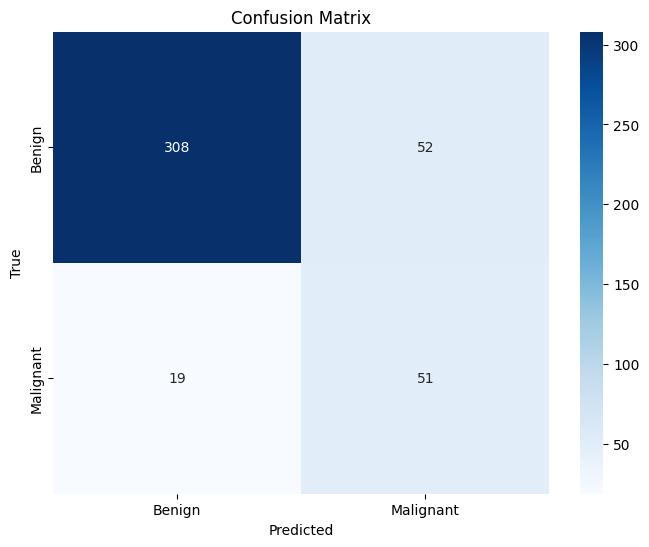

Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      0.86      0.90       360
         1.0       0.50      0.73      0.59        70

    accuracy                           0.83       430
   macro avg       0.72      0.79      0.74       430
weighted avg       0.87      0.83      0.85       430



In [ ]:
# Testing model on test data to evaluate
lists=[]
y_pred = model.predict(X_test)
for i in range(len(y_pred)):
    if y_pred[i][0]>0.5:
        lists.append(1)
    else:
        lists.append(0)

print(accuracy_score(Y_test, lists))


# Confusion Matrix
conf_matrix = confusion_matrix(Y_test, lists)

# Classification Report
class_report = classification_report(Y_test, lists)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Print Classification Report
print("Classification Report:\n", class_report)

In [ ]:
i=0
prop_class=[]
mis_class=[]

for i in range(len(Y_test)):
    if(Y_test[i]==lists[i]):
        prop_class.append(i)
    if(len(prop_class)==8):
        break

i=0
for i in range(len(Y_test)):
    if(not Y_test[i]==lists[i]):
        mis_class.append(i)
    if(len(mis_class)==8):
        break

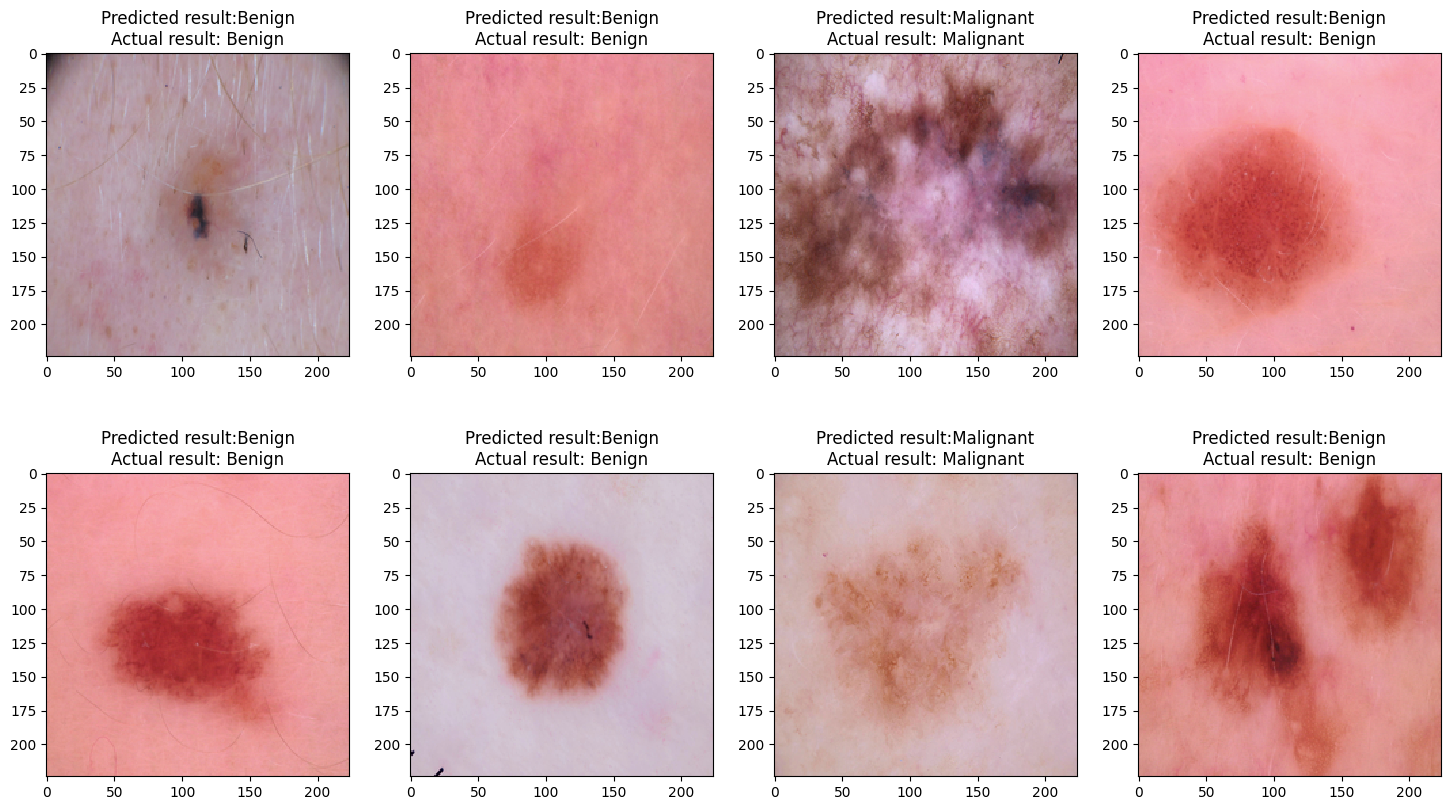

In [ ]:
w=60
h=40
fig=plt.figure(figsize=(18, 10))
columns = 4
rows = 2

def Transfername(namecode):
    if namecode==0:
        return "Benign"
    else:
        return "Malignant"

for i in range(len(prop_class)):
    ax = fig.add_subplot(rows, columns, i+1)
    ax.set_title("Predicted result:"+ Transfername(lists[prop_class[i]])
                       +"\n"+"Actual result: "+ Transfername(Y_test[prop_class[i]]))
    plt.imshow(X_test[prop_class[i]], interpolation='nearest')
plt.show()

VGG 16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# Define VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=optimizers.Adam(lr=0.0001), loss='binary_crossentropy', metrics=['accuracy'])





58889256/58889256 [==============================] - 0s 0us/step


In [ ]:
batch_size = 32
epochs = 10

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=batch_size),
    steps_per_epoch=len(x_train) / batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val)
)

Epoch 1/10
59/59 [==============================] - 1321s 22s/step - loss: 1.0888 - accuracy: 0.7802 - val_loss: 0.5488 - val_accuracy: 0.7544
Epoch 2/10
59/59 [==============================] - 1328s 22s/step - loss: 0.4487 - accuracy: 0.8016 - val_loss: 0.4922 - val_accuracy: 0.8284
Epoch 3/10
59/59 [==============================] - 1329s 22s/step - loss: 0.4113 - accuracy: 0.8298 - val_loss: 0.4080 - val_accuracy: 0.8225
Epoch 4/10
59/59 [==============================] - 1324s 22s/step - loss: 0.4167 - accuracy: 0.8282 - val_loss: 0.4365 - val_accuracy: 0.8373
Epoch 5/10
59/59 [==============================] - 1325s 22s/step - loss: 0.3836 - accuracy: 0.8303 - val_loss: 0.4056 - val_accuracy: 0.8580
Epoch 6/10
59/59 [==============================] - 1329s 22s/step - loss: 0.3445 - accuracy: 0.8454 - val_loss: 0.3432 - val_accuracy: 0.8402
Epoch 7/10
59/59 [==============================] - 1327s 22s/step - loss: 0.3795 - accuracy: 0.8386 - val_loss: 0.4158 - val_accuracy: 0.8491

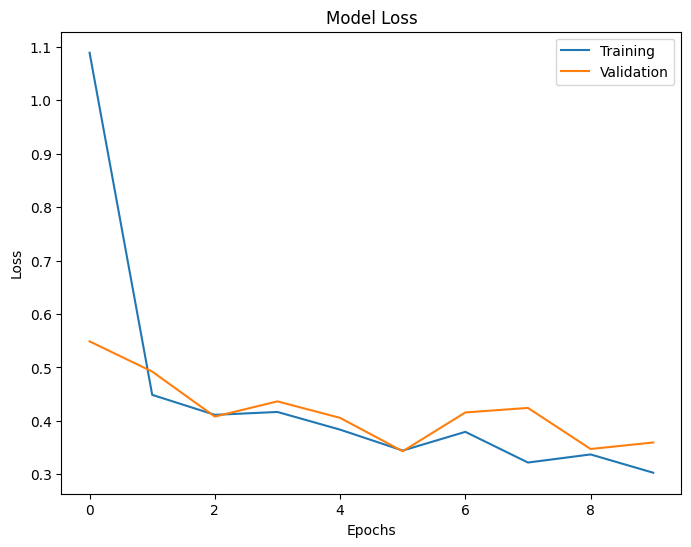

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have history from your training process
plt.figure(figsize=(8, 6))  # Adjust the figsize as needed
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()


14/14 [==============================] - 269s 19s/step
0.7813953488372093


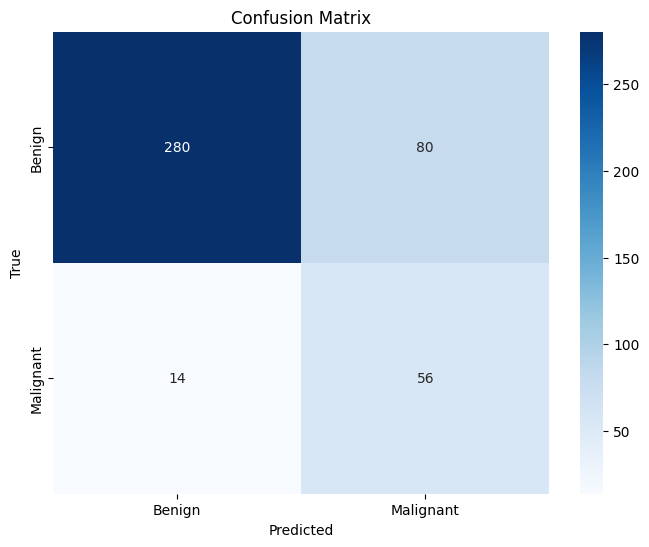

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.78      0.86       360
         1.0       0.41      0.80      0.54        70

    accuracy                           0.78       430
   macro avg       0.68      0.79      0.70       430
weighted avg       0.86      0.78      0.81       430



In [ ]:
# Testing model on test data to evaluate
lists=[]
y_pred = model.predict(X_test)
for i in range(len(y_pred)):
    if y_pred[i][0]>0.5:
        lists.append(1)
    else:
        lists.append(0)

print(accuracy_score(Y_test, lists))


# Confusion Matrix
conf_matrix = confusion_matrix(Y_test, lists)

# Classification Report
class_report = classification_report(Y_test, lists)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Print Classification Report
print("Classification Report:\n", class_report)

In [ ]:
i=0
prop_class=[]
mis_class=[]

for i in range(len(Y_test)):
    if(Y_test[i]==lists[i]):
        prop_class.append(i)
    if(len(prop_class)==8):
        break

i=0
for i in range(len(Y_test)):
    if(not Y_test[i]==lists[i]):
        mis_class.append(i)
    if(len(mis_class)==8):
        break

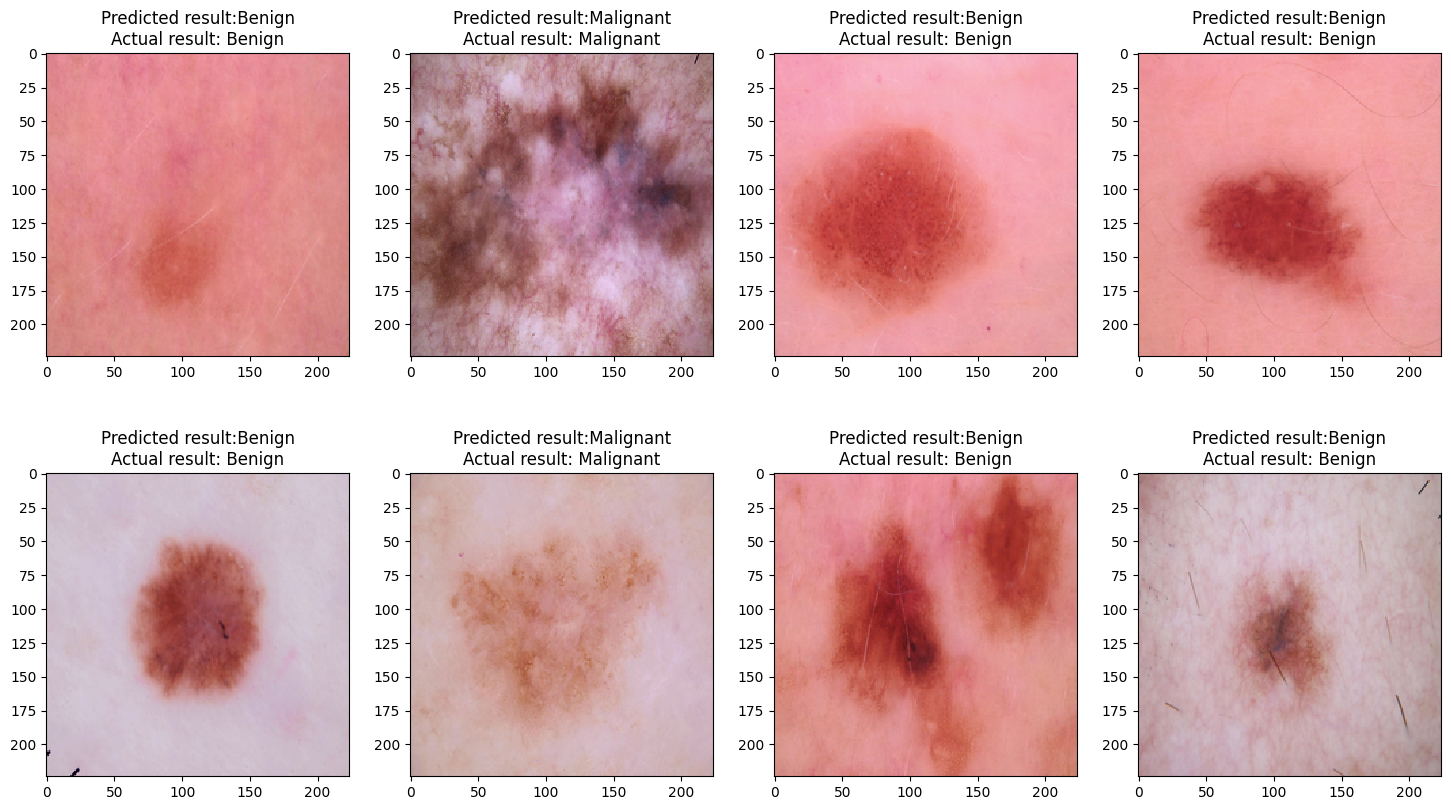

In [ ]:
w=60
h=40
fig=plt.figure(figsize=(18, 10))
columns = 4
rows = 2

def Transfername(namecode):
    if namecode==0:
        return "Benign"
    else:
        return "Malignant"

for i in range(len(prop_class)):
    ax = fig.add_subplot(rows, columns, i+1)
    ax.set_title("Predicted result:"+ Transfername(lists[prop_class[i]])
                       +"\n"+"Actual result: "+ Transfername(Y_test[prop_class[i]]))
    plt.imshow(X_test[prop_class[i]], interpolation='nearest')
plt.show()